   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


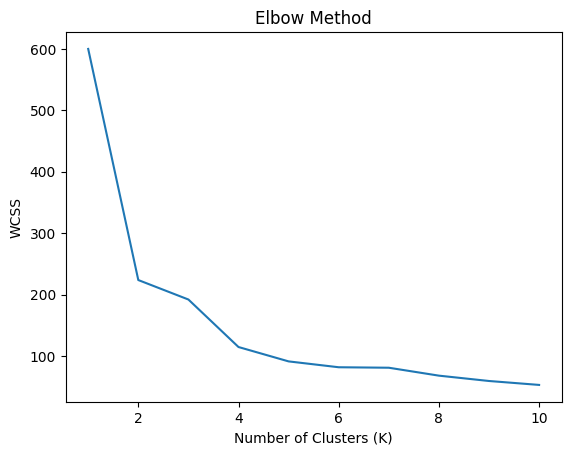

   sepal_length  sepal_width  petal_length  petal_width      species  Cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        2
2           4.7          3.2           1.3          0.2  Iris-setosa        2
3           4.6          3.1           1.5          0.2  Iris-setosa        2
4           5.0          3.6           1.4          0.2  Iris-setosa        1
Centroids:
 [[ 0.57100359 -0.36600236  0.69108416  0.66322635]
 [-0.80601877  1.33577362 -1.28618375 -1.21026347]
 [-1.31926109 -0.34584225 -1.14482725 -1.1336954 ]]


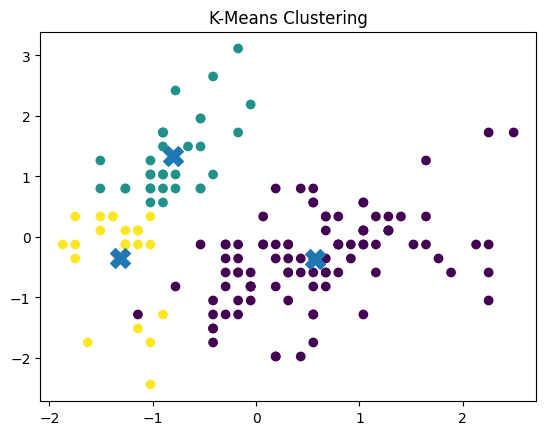

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load Dataset
# -----------------------------
data = pd.read_csv("/content/iris (2) (1).csv")   # replace with your file name

print(data.head())

# -----------------------------
# 2. Select Features (drop label if exists)
# -----------------------------
# If dataset has label column like 'Species' or 'Target'
X = data.select_dtypes(include=['float64', 'int64'])

# -----------------------------
# 3. Feature Scaling (VERY IMPORTANT)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 4. Elbow Method (to find best K)
# -----------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# -----------------------------
# 5. Apply K-Means
# -----------------------------
k = 3   # choose based on elbow graph
kmeans = KMeans(n_clusters=k, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# -----------------------------
# 6. Add Cluster Labels
# -----------------------------
data['Cluster'] = y_kmeans

print(data.head())

# -----------------------------
# 7. Centroids
# -----------------------------
print("Centroids:\n", kmeans.cluster_centers_)

# -----------------------------
# 8. Visualization (only if 2 features)
# -----------------------------
if X.shape[1] >= 2:
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
    plt.scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                s=200, marker='X')
    plt.title("K-Means Clustering")
    plt.show()